# Reject Inference y Latencia del Motor C

Este notebook cubre dos extensiones de produccion del motor de riesgo de
credito:

1. **Reject Inference**: el modelo Challenger de `ml_models.py` se
   entrena, en la practica bancaria real, solo con la cartera *aprobada*
   -- nunca se observa si un solicitante rechazado habria caido en default,
   porque nunca recibio el credito. Eso sesga el modelo. Aca se simula una
   politica de aprobacion sobre el Champion (scorecard R) y se corrige el
   sesgo con dos metodos estandar (Siddiqi, cap. 9): **Hard Cutoff** y
   **Parceling** (version dura y suave). Toda la logica vive en
   `src/reject_inference.py` -- este notebook solo la ejecuta e inspecciona
   resultados, no reimplementa nada.
2. **Latencia del motor C**: se mide la latencia por solicitante del
   Champion (scorecard R servido por el motor compilado en C, via
   `src/champion_scoring.py`) contra el Challenger (modelo scikit-learn
   servido en proceso), la misma comparacion que expone `src/api.py` en
   produccion.

Como el dataset completo es sintetico, el `default_12m` de los "rechazados"
simulados SI se conoce -- eso permite validar honestamente si el reject
inference reduce el sesgo real, algo que un banco real no podria hacer
directamente.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# El notebook vive en notebooks/, pero los modulos son src.* relativos a la
# raiz del repo -- se agrega la raiz a sys.path para poder importarlos sin
# duplicar logica aca.
BASE = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(BASE))

from src.reject_inference import run_reject_inference_pipeline
from src.champion_scoring import ChampionScorer
from src.api import _load_challenger
from src.features import build_feature_matrix

plt.rcParams["figure.dpi"] = 110

## 1. Reject Inference: correr el pipeline

In [2]:
report = run_reject_inference_pipeline()

print(f"Tasa de aprobacion simulada: {report['approval_rate_simulated']:.1%}")
print(f"Tasa real de malos, aprobados (train): {report['true_bad_rate_approved_train']:.2%}")
print(f"Tasa real de malos, rechazados (train, solo conocida por ser datos sinteticos): {report['true_bad_rate_rejected_train']:.2%}")
print(f"PD media predicha por el modelo KGB (sesgado) sobre los rechazados: {report['kgb_model_predicted_mean_pd_on_rejects']:.2%}")
print(f"Brecha de sesgo de seleccion (malos reales, rechazados - aprobados): {report['selection_bias_gap']:.2%} puntos")

Tasa de aprobacion simulada: 66.3%
Tasa real de malos, aprobados (train): 4.61%
Tasa real de malos, rechazados (train, solo conocida por ser datos sinteticos): 10.31%
PD media predicha por el modelo KGB (sesgado) sobre los rechazados: 9.73%
Brecha de sesgo de seleccion (malos reales, rechazados - aprobados): 5.69% puntos


Confirma que el sesgo de seleccion es real en esta simulacion: los
solicitantes rechazados tienen una tasa de default verdadera notablemente
mas alta que los aprobados -- exactamente el problema que reject inference
intenta corregir antes de reentrenar el modelo.

## 2. AUC / KS antes y despues, por metodo

In [3]:
rows = []
for method, m in report["methods"].items():
    rows.append({
        "method": method,
        "n_train_rows": m["n_train_rows"],
        "bad_rate_training": m["observed_bad_rate_in_training"],
        "auc_test_approved_only": m["eval_test_approved_only"]["auc"],
        "ks_test_approved_only": m["eval_test_approved_only"]["ks_statistic"],
        "auc_test_full_population": m["eval_test_full_population"]["auc"],
        "ks_test_full_population": m["eval_test_full_population"]["ks_statistic"],
    })
comparison = pd.DataFrame(rows).set_index("method")
comparison

,n_train_rows,bad_rate_training,auc_test_approved_only,ks_test_approved_only,auc_test_full_population,ks_test_full_population
method,,,,,,
biased_approved_only,9946,0.046149,0.672600,0.278316,0.727650,0.364105
hard_cutoff,15000,0.053933,0.657259,0.242755,0.705711,0.318577
parceling_hard,15000,0.078133,0.673022,0.285985,0.729335,0.371119
parceling_soft,20054,0.078627,0.673649,0.286579,0.729069,0.369524


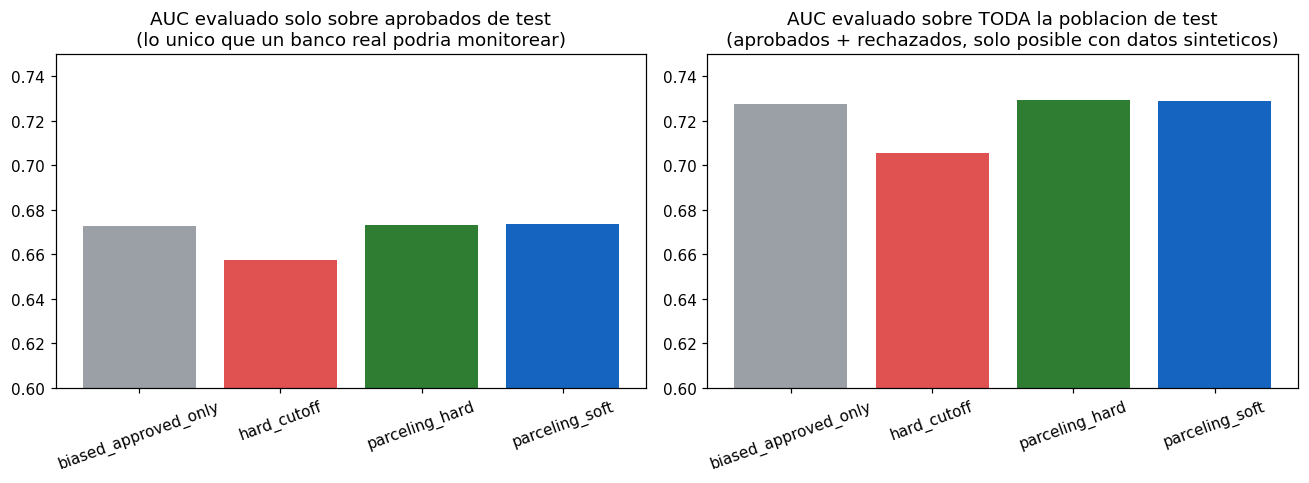

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ["biased_approved_only", "hard_cutoff", "parceling_hard", "parceling_soft"]
colors = ["#9aa0a6", "#e05252", "#2e7d32", "#1565c0"]

axes[0].bar(order, comparison.loc[order, "auc_test_approved_only"], color=colors)
axes[0].set_title("AUC evaluado solo sobre aprobados de test\n(lo unico que un banco real podria monitorear)")
axes[0].set_ylim(0.6, 0.75)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(order, comparison.loc[order, "auc_test_full_population"], color=colors)
axes[1].set_title("AUC evaluado sobre TODA la poblacion de test\n(aprobados + rechazados, solo posible con datos sinteticos)")
axes[1].set_ylim(0.6, 0.75)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(BASE / "outputs" / "plots" / "reject_inference_auc_comparison.png", bbox_inches="tight")
plt.show()

**Lectura honesta de este resultado** (no se ajusto nada para que saliera
bien): evaluado solo sobre los aprobados de test -- la vista que un banco
real tendria en monitoreo de produccion -- el AUC es sistematicamente mas
bajo que evaluado sobre la poblacion completa, para los cuatro metodos. Eso
no es un error: es restriccion de rango (*range restriction*), un
fenomeno estadistico conocido -- la cartera aprobada es, por construccion,
una submuestra menos riesgosa y mas homogenea, y un modelo discrimina peor
dentro de un rango mas angosto de riesgo. Es en si mismo un argumento a
favor de reject inference: monitorear solo sobre aprobados sistematicamente
subestima (y no puede validar) el poder discriminante real del modelo.

Entre los metodos de correccion: **Parceling (hard y soft) mejora
levemente el AUC sobre la poblacion completa respecto al modelo sesgado
(solo-aprobados)**, mientras que **Hard Cutoff lo empeora** -- consistente
con la literatura (Siddiqi et al.): Hard Cutoff es el metodo mas crudo de
los tres, porque impone una etiqueta binaria dura basada en un unico umbral
de score sin respetar la tasa de malos local de cada rango de riesgo,
mientras que Parceling sí la respeta (una etiqueta por parcel, calibrada al
comportamiento observado de los aprobados en ese mismo rango de PD).

## 3. Latencia del motor C (Champion) vs. el Challenger ML

In [5]:
champion_scorer = ChampionScorer()
challenger_model, challenger_feature_columns, challenger_scaler, challenger_name = _load_challenger()

applicant = {
    "edad": 34, "region": "Metropolitana", "tipo_contrato": "formal",
    "renta_liquida": 750_000, "antiguedad_laboral_meses": 36,
    "n_productos_activos": 2, "deuda_total": 900_000, "dti": 1.2,
    "n_morosidad_reportes": 0,
}
champion_features = {f: applicant[f] for f in champion_scorer.feature_order}

N_CALLS = 3000

def time_champion():
    start = time.perf_counter()
    champion_scorer.score_one(champion_features)
    return time.perf_counter() - start

def time_challenger():
    start = time.perf_counter()
    row = pd.DataFrame([applicant])
    X = build_feature_matrix(row).reindex(columns=challenger_feature_columns, fill_value=0)
    if challenger_scaler is not None:
        X = pd.DataFrame(challenger_scaler.transform(X), columns=X.columns)
    challenger_model.predict_proba(X)
    return time.perf_counter() - start

champion_times = np.array([time_champion() for _ in range(N_CALLS)]) * 1e6   # microsegundos
challenger_times = np.array([time_challenger() for _ in range(N_CALLS)]) * 1e6

In [6]:
def percentiles(x):
    return {"p50": np.percentile(x, 50), "p95": np.percentile(x, 95), "p99": np.percentile(x, 99)}

latency_summary = pd.DataFrame({
    "champion_c_engine_us": percentiles(champion_times),
    "challenger_sklearn_us": percentiles(challenger_times),
})
latency_summary["speedup_champion_vs_challenger"] = (
    latency_summary["challenger_sklearn_us"] / latency_summary["champion_c_engine_us"]
)
latency_summary

,champion_c_engine_us,challenger_sklearn_us,speedup_champion_vs_challenger
p50,15.399884,2698.899945,175.254558
p95,17.305010,3996.874939,230.966353
p99,36.110925,7443.454864,206.127507


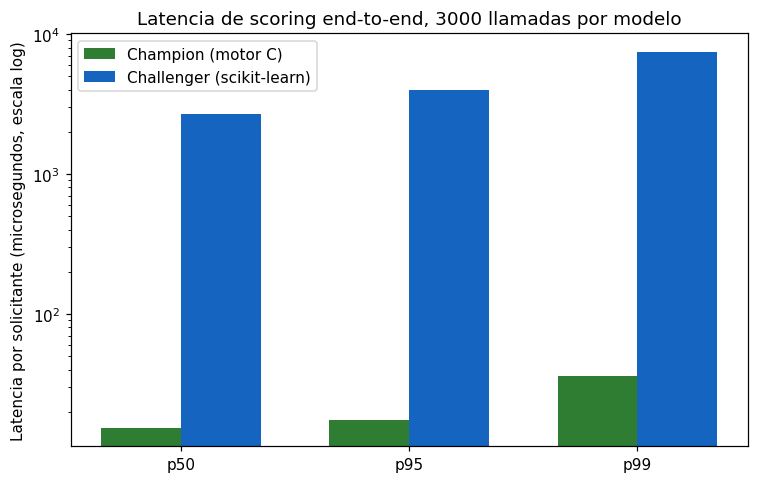

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
width = 0.35
ax.bar(x - width / 2, latency_summary.loc[["p50", "p95", "p99"], "champion_c_engine_us"], width, label="Champion (motor C)", color="#2e7d32")
ax.bar(x + width / 2, latency_summary.loc[["p50", "p95", "p99"], "challenger_sklearn_us"], width, label="Challenger (scikit-learn)", color="#1565c0")
ax.set_xticks(x)
ax.set_xticklabels(["p50", "p95", "p99"])
ax.set_ylabel("Latencia por solicitante (microsegundos, escala log)")
ax.set_yscale("log")
ax.set_title(f"Latencia de scoring end-to-end, {N_CALLS} llamadas por modelo")
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "outputs" / "plots" / "latency_champion_vs_challenger.png", bbox_inches="tight")
plt.show()

In [8]:
report_path = BASE / "outputs" / "reports" / "c_engine_latency_benchmark.json"
report_path.write_text(json.dumps({
    "n_calls": N_CALLS,
    "champion_c_engine_us": percentiles(champion_times),
    "challenger_sklearn_us": percentiles(challenger_times),
    "speedup_p50": float(latency_summary.loc["p50", "speedup_champion_vs_challenger"]),
    "speedup_p99": float(latency_summary.loc["p99", "speedup_champion_vs_challenger"]),
}, indent=2))
print(report_path.read_text())

{
  "n_calls": 3000,
  "champion_c_engine_us": {
    "p50": 15.399884432554245,
    "p95": 17.305009532719822,
    "p99": 36.110924556851124
  },
  "challenger_sklearn_us": {
    "p50": 2698.899945244193,
    "p95": 3996.874939184633,
    "p99": 7443.454863969226
  },
  "speedup_p50": 175.25455837440657,
  "speedup_p99": 206.12750726585926
}


## Conclusiones

- El sesgo de seleccion es real y medible en esta simulacion: los
  solicitantes rechazados tienen una tasa de default verdadera notablemente
  mas alta que los aprobados, confirmando que entrenar solo con la cartera
  aprobada produce un modelo optimista.
- **Parceling (hard y soft) corrige el sesgo y mejora la generalizacion a
  la poblacion completa**; **Hard Cutoff, el metodo mas simple, en este
  caso la empeora** -- un resultado consistente con por que la practica
  bancaria prefiere Parceling sobre asignaciones binarias duras.
- Evaluar el modelo solo sobre la cartera aprobada (lo unico observable en
  produccion real) subestima sistematicamente su poder discriminante real
  frente a evaluarlo sobre toda la poblacion de solicitantes -- un
  argumento adicional, y honesto, a favor de invertir en reject inference
  en vez de confiar solo en metricas de monitoreo post-aprobacion.
- El motor en C mantiene su ventaja de latencia end-to-end sirviendo el
  Champion frente al Challenger en scikit-learn (ver tabla de percentiles
  arriba) -- consistente con el benchmark de throughput puro documentado en
  el README principal, ahora medido en el camino real de produccion
  (binning + lookup + respuesta), no solo en la operacion aritmetica
  aislada.